# Black-hole binary formation channels with gaussian mixtures

In [1]:
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
import numpy as np
from matplotlib import pyplot as plt
import math

from sklearn.mixture import GaussianMixture

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
data=np.load('formationchannels.npy')

In [3]:
data.shape

(2950, 1)

I would like to figure out how many formation channels are at play

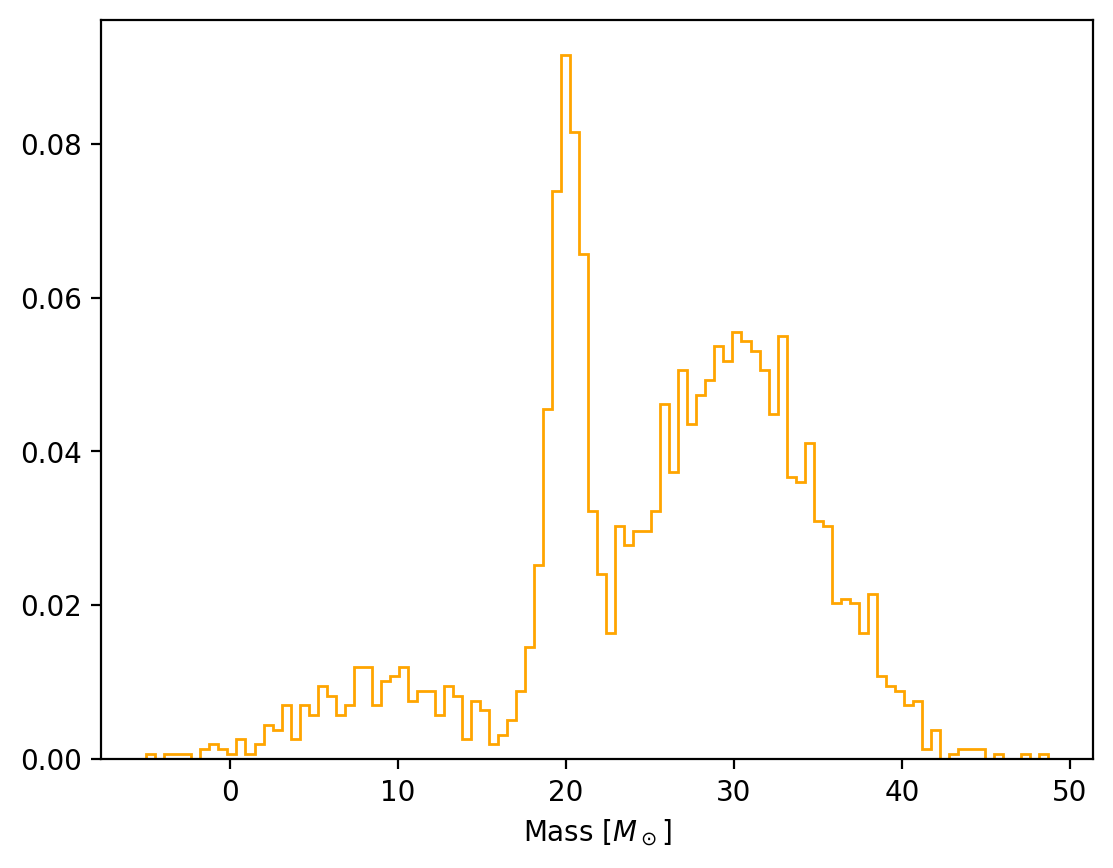

In [4]:
plt.hist(data, bins=100, histtype='step', color='orange',density=True)
plt.xlabel("Mass $[M_\odot]$");

From a quick histrogram visualization it seems that 3 modes are present. Now I want to use a Gaussian Mixture model to fit data: the model is a sum of N gaussians. 

I fit my data with different models, each with 1,2,3...,10 gaussians components, and keep track of the AIC

In [5]:
aic=[]
for N in range (1,11):
    GaussMix=GaussianMixture(n_components=N).fit(data)
    aic.append(GaussMix.aic(data))

Text(0, 0.5, 'AIC')

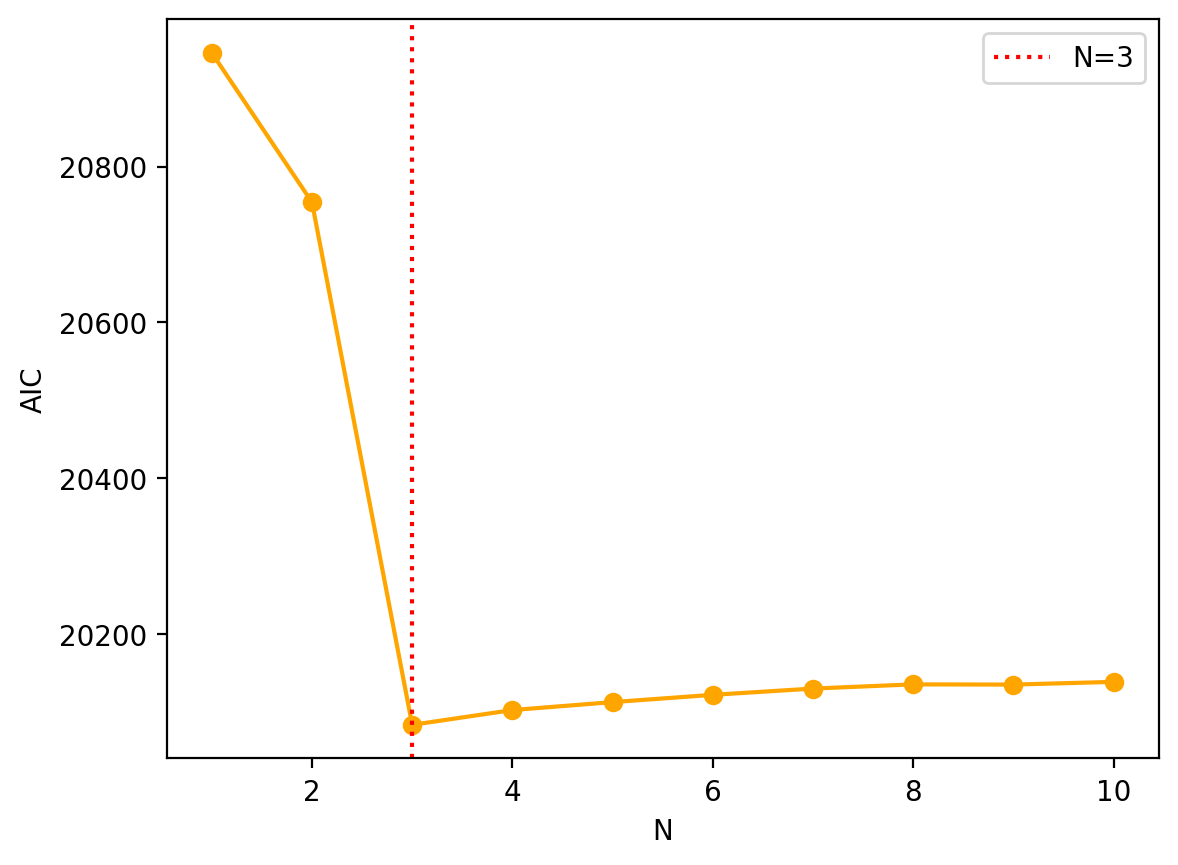

In [6]:
N=np.linspace(1,10,10)
plt.plot(N,aic, c='orange')
plt.scatter(N,aic, color='orange')
plt.axvline(3,c='red', ls='dotted', label='N=3')
plt.legend()
plt.xlabel('N')
plt.ylabel('AIC')

AIC is minimized for N=3 components -> visualize the GaussianMixture model with N=3 over the data

In [7]:
model = GaussianMixture(n_components=3)
gm = model.fit(data)

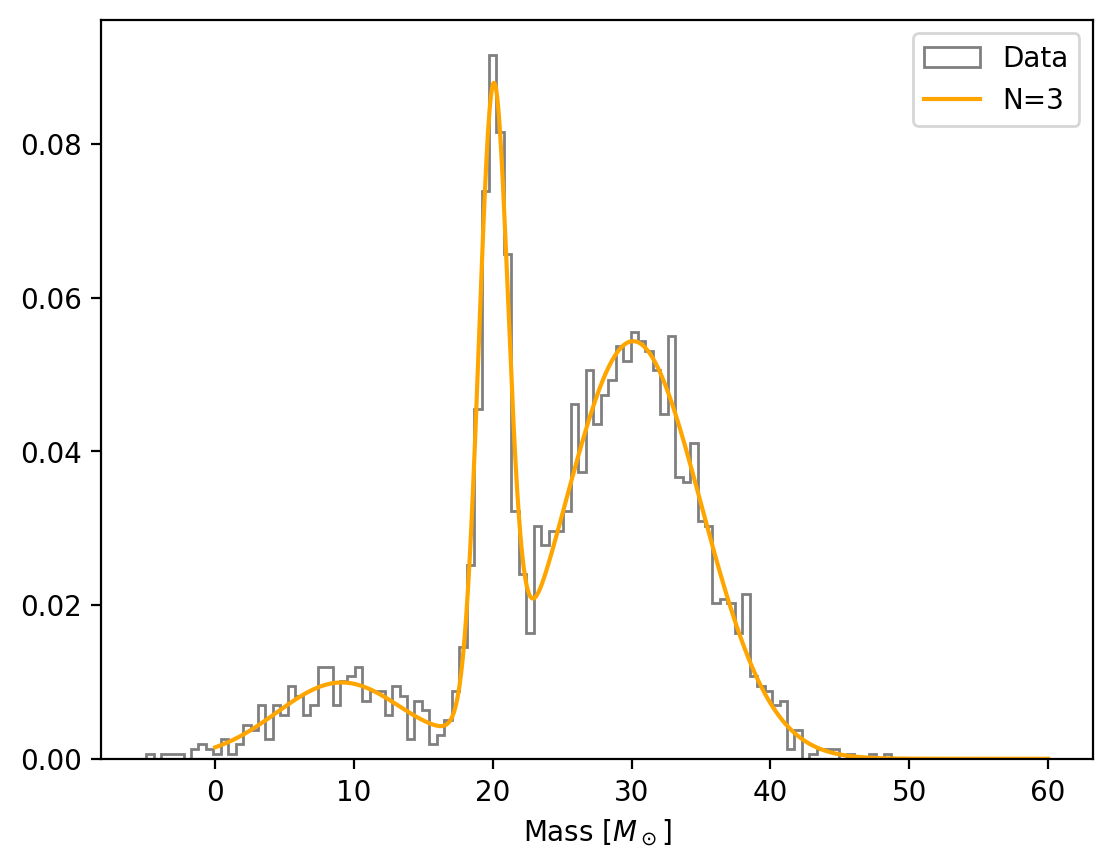

In [8]:
xi = np.linspace(0, 60, 1000)
x = xi[:,np.newaxis]

logprob = model.score_samples(x)
pdf = np.exp(logprob)

plt.hist(data, bins=100, histtype='step', alpha=0.5, color='black',density=True, label='Data')

plt.plot(x, pdf, color='orange', label='N=3')

plt.xlabel(r'Mass $[M_\odot]$')
plt.legend()
plt.show()

I visualize the single modes contributing to my model 

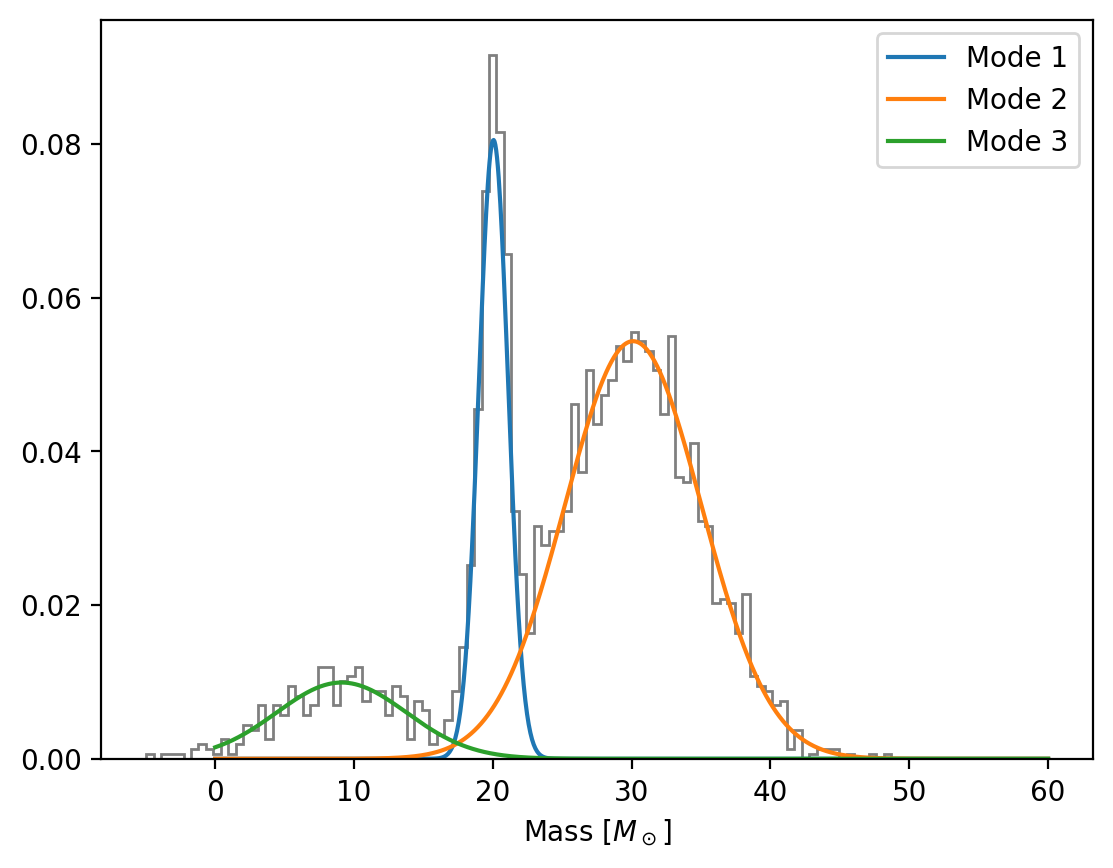

In [9]:
responsibilities = model.predict_proba(x)
pdf_individual = responsibilities * pdf[:, np.newaxis]

plt.hist(data, 100, density=True, histtype='step', alpha=0.5, color='black')
plt.plot(x, pdf_individual[:,0],label="Mode 1")
plt.plot(x, pdf_individual[:,1],label="Mode 2")
plt.plot(x, pdf_individual[:,2],label="Mode 3")

plt.xlabel(r'Mass $[M_\odot]$')
plt.legend()
plt.show()

If i try with another model (for example N=2), the fit is bad

In [10]:
model = GaussianMixture(n_components=2)
gm = model.fit(data)

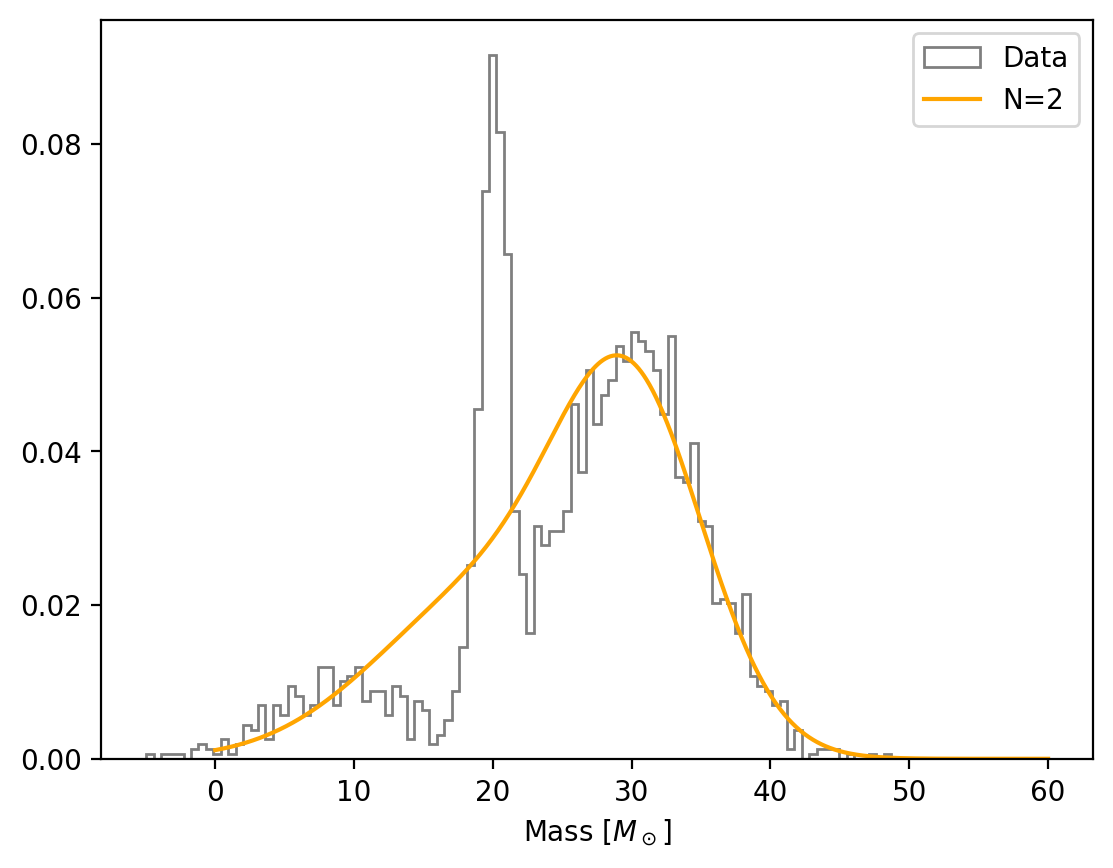

In [11]:
xi = np.linspace(0, 60, 1000)
x = xi[:,np.newaxis]

logprob = model.score_samples(x)
pdf = np.exp(logprob)

plt.hist(data, bins=100, histtype='step', alpha=0.5, color='black',density=True, label='Data')

plt.plot(x, pdf, color='orange', label='N=2')

plt.xlabel(r'Mass $[M_\odot]$')
plt.legend()
plt.show()

or N=5

In [12]:
model = GaussianMixture(n_components=5)
gm = model.fit(data)

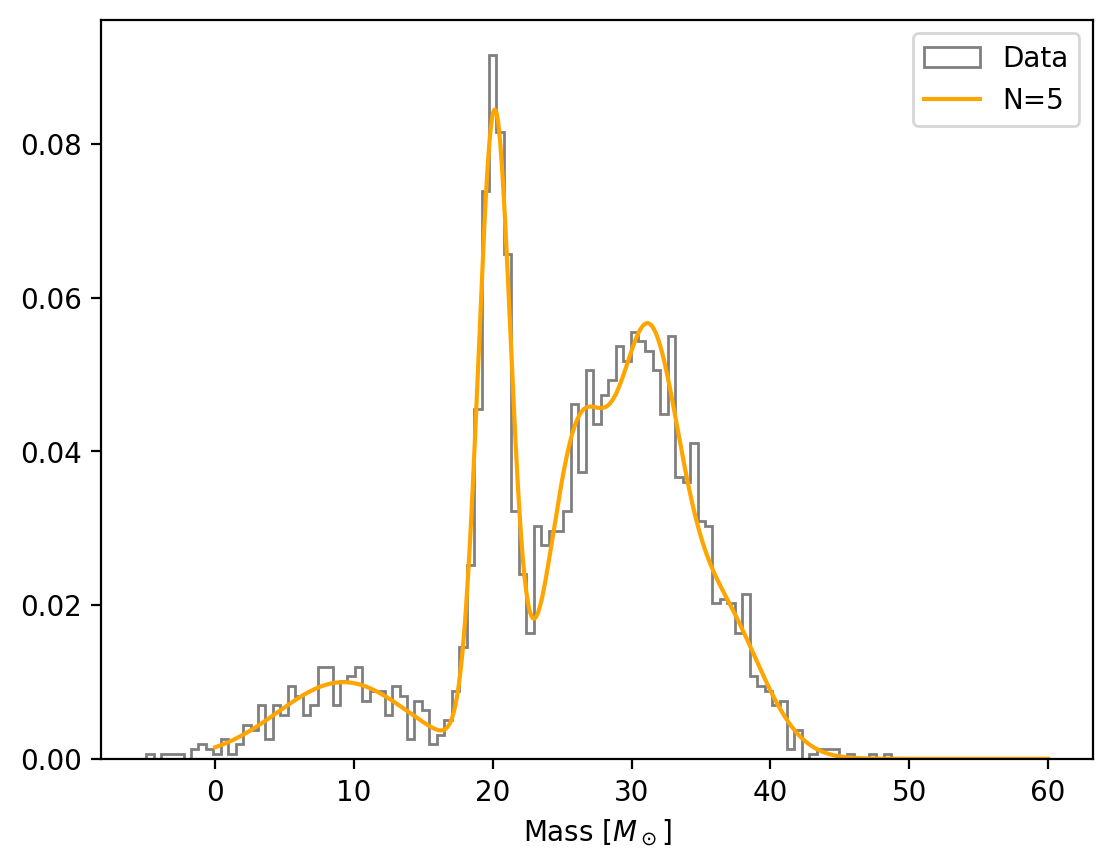

In [13]:
xi = np.linspace(0, 60, 1000)
x = xi[:,np.newaxis]

logprob = model.score_samples(x)
pdf = np.exp(logprob)

plt.hist(data, bins=100, histtype='step', alpha=0.5, color='black',density=True, label='Data')

plt.plot(x, pdf, color='orange', label='N=5')

plt.xlabel(r'Mass $[M_\odot]$')
plt.legend()
plt.show()

It seems that the 5 components model captures more details, but the N=3 model is preferred since it is simpler